# 🧠 Customer Retention Intelligence System
**Dataset:** E-Commerce Customer Churn  
**Goal:** Predict who will churn, why, when, and what action will stop them  
**Model:** XGBoost Classifier  
**Phases:** Data Prep → Risk Model → Behavior Profiling → Urgency → Decision Engine → Simulation

## 📦 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

## 🗂️ 2. Load Data

In [2]:
DATA_PATH = r'C:\Users\Oni Taiwo\Documents\Data_Science_Projects\customer_retention_intelligence\data\E Commerce Dataset.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='E Comm')
print(f'Shape: {df.shape}')
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 🧹 3. Data Preparation
### 3.1 Missing Values

In [3]:
# Check missing values as percentage
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0])

Tenure                         4.689165
WarehouseToHome                4.458259
HourSpendOnApp                 4.529307
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
dtype: float64


### 3.2 Duplicates

In [4]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


### 3.3 Check Skewness & Fill NaNs

In [5]:
cols_with_na = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']

print(df[cols_with_na].skew())

Tenure                         0.736513
WarehouseToHome                1.619154
HourSpendOnApp                -0.027213
OrderAmountHikeFromlastYear    0.790785
CouponUsed                     2.545653
OrderCount                     2.196414
DaySinceLastOrder              1.191000
dtype: float64


In [ ]:
# Skewed columns → median | Normal columns → mean
median_cols = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear',
               'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].mean())

print('Missing values after fill:', df.isnull().sum().sum())

Missing values after fill: 0


C:\Users\Oni Taiwo\AppData\Local\Temp\ipykernel_6640\2636390031.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Oni Taiwo\AppData\Local\Temp\ipykernel_6640\2636390031.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

### 3.4 Clean & Fix Data Types

In [7]:
# Fix inconsistent category names
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile Phone': 'Mobile'})
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Mobile Phone': 'Phone'})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card', 'COD': 'Cash on Delivery', 'E wallet': 'E-wallet'
})

# Fix data types
for col in ['Tenure', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder',
            'HourSpendOnApp', 'OrderAmountHikeFromlastYear']:
    df[col] = df[col].astype(int)

# Drop ID column
df.drop(columns=['CustomerID'], inplace=True)

print('Data types fixed.')
df.info()

Data types fixed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   int64  
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5630 non-null   int64  
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  

## 📊 4. Exploratory Data Analysis

In [8]:
df.describe(include='all')

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630,5630.000000,5630.000000,5630,5630,5630.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
unique,NaN,NaN,2,NaN,NaN,5,2,NaN,NaN,5,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Mobile,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,3996,NaN,NaN,2314,3384,NaN,NaN,2080,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.168384,10.134103,NaN,1.654707,15.566785,NaN,NaN,2.889343,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.223030
std,0.374240,8.357951,NaN,0.915389,8.345961,NaN,NaN,0.731503,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.207036
min,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,3.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,0.000000,15.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500


### 4.1 Churn Distribution

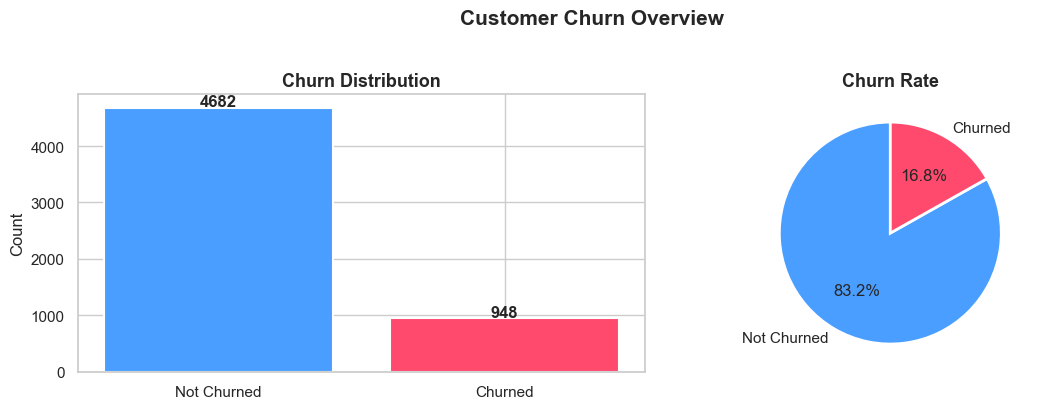

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values,
            color=['#4a9eff', '#ff4a6e'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            colors=['#4a9eff', '#ff4a6e'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Correlation with Churn

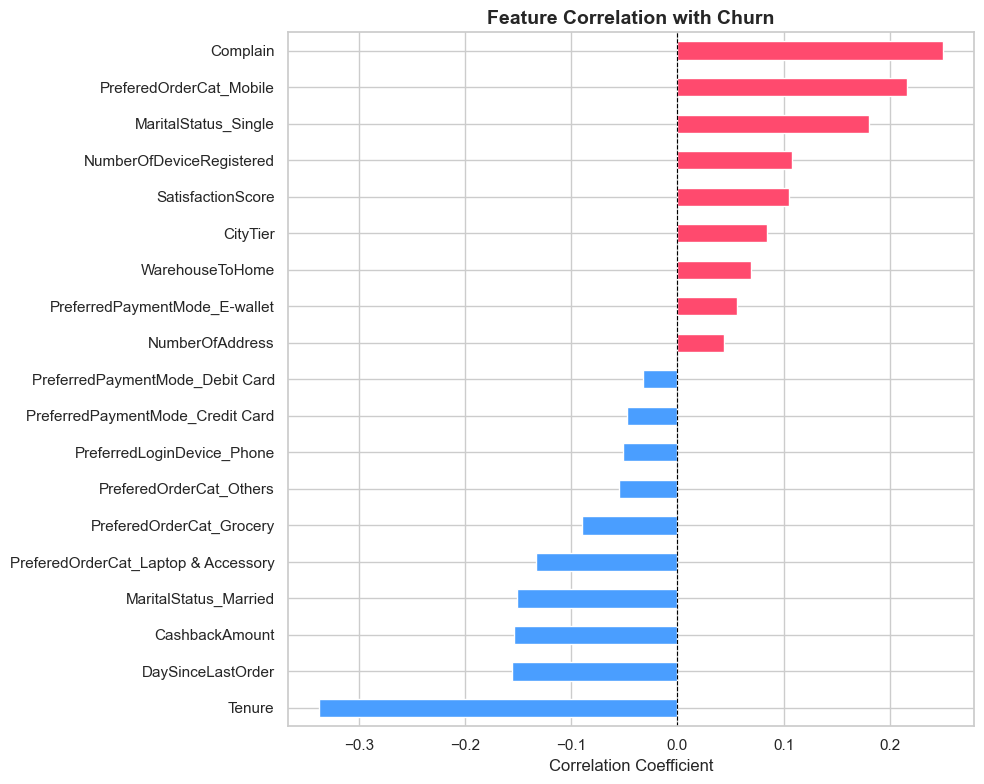

In [10]:
# One Hot Encode categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Drop weak signal columns
drop_cols = ['Gender_Male', 'HourSpendOnApp', 'PreferredPaymentMode_UPI',
             'CouponUsed', 'OrderAmountHikeFromlastYear', 'OrderCount']
df.drop(columns=drop_cols, inplace=True)

# Plot correlation
corr = df.corr()['Churn'].drop('Churn').sort_values()
colors = ['#ff4a6e' if x > 0 else '#4a9eff' for x in corr.values]

plt.figure(figsize=(10, 8))
corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 🤖 5. Risk Model — Who Will Churn?
### 5.1 Train / Test Split

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train churn rate:')
print(y_train.value_counts(normalize=True))
print('\nTest churn rate:')
print(y_test.value_counts(normalize=True))

Train churn rate:
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

Test churn rate:
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64


### 5.2 Train XGBoost

In [12]:
# scale_pos_weight=5 handles class imbalance (5 non-churned per 1 churned)
model_xgb = XGBClassifier(random_state=42, scale_pos_weight=5, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.94      0.97      0.95       190

    accuracy                           0.98      1126
   macro avg       0.97      0.98      0.97      1126
weighted avg       0.98      0.98      0.98      1126



### 5.3 Feature Importance

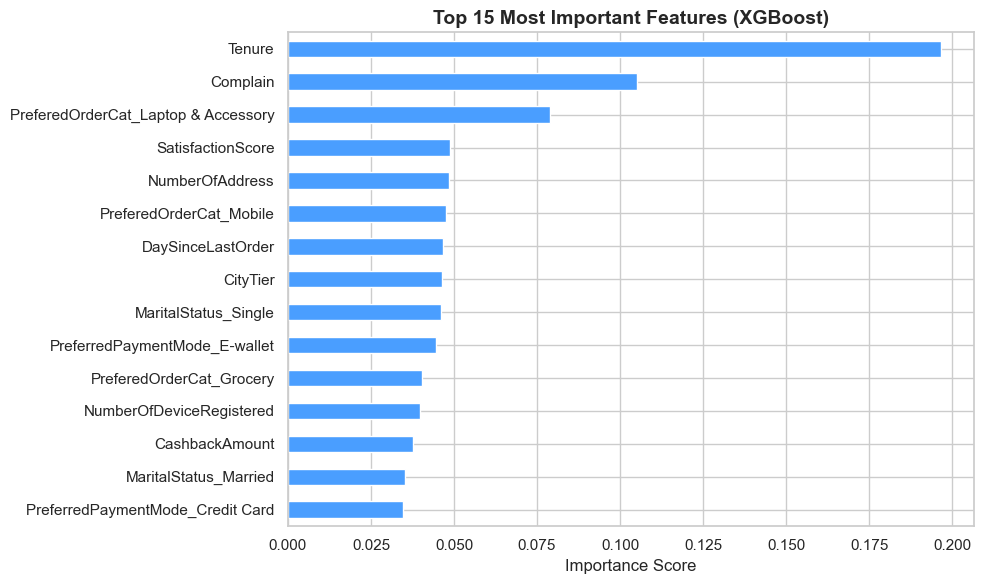

In [13]:
importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='#4a9eff', edgecolor='white')
plt.title('Top 15 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 5.4 Save Model

In [14]:
joblib.dump(model_xgb, 'churn_model.pkl')
print('Model saved.')

Model saved.


### 5.5 Assign Probability Scores & Risk Labels

In [15]:
churn_proba = model_xgb.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy['Churn_Probability'] = churn_proba
X_test_copy['Churn_Actual'] = y_test.values

def risk_label(prob):
    if prob >= 0.7:
        return 'High'
    elif prob >= 0.4:
        return 'Medium'
    else:
        return 'Low'

X_test_copy['Risk_Level'] = X_test_copy['Churn_Probability'].apply(risk_label)
print(X_test_copy['Risk_Level'].value_counts())

Risk_Level
Low       926
High      188
Medium     12
Name: count, dtype: int64


### 5.6 Risk Level Distribution

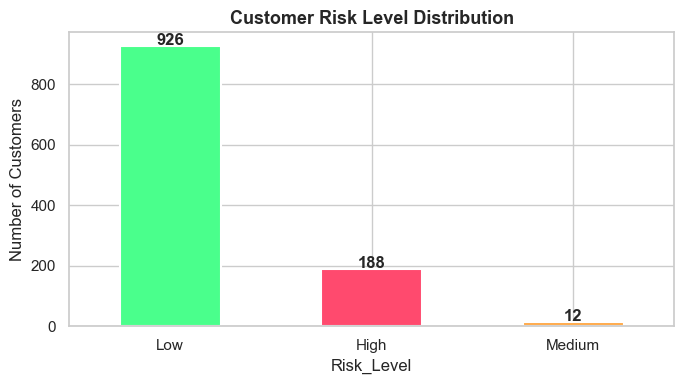

In [16]:
risk_counts = X_test_copy['Risk_Level'].value_counts()
colors = {'High': '#ff4a6e', 'Medium': '#ffaa4a', 'Low': '#4aff8c'}
bar_colors = [colors[r] for r in risk_counts.index]

plt.figure(figsize=(7, 4))
risk_counts.plot(kind='bar', color=bar_colors, edgecolor='white', linewidth=1.5)
plt.title('Customer Risk Level Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🧠 6. Behavior Profiling — Why Will They Churn?

In [17]:
# Engineer behavior signals
X_test_copy['Frustration_Score'] = (
    (X_test_copy['Complain'] == 1) &
    (X_test_copy['SatisfactionScore'] <= 2)
).astype(int)

X_test_copy['Inactive'] = (
    X_test_copy['DaySinceLastOrder'] >= 4
).astype(int)

X_test_copy['Price_Sensitive'] = (
    X_test_copy['CashbackAmount'] < X_test_copy['CashbackAmount'].median()
).astype(int)

def behavior_profile(row):
    if row['Frustration_Score'] == 1:
        return 'Frustrated'
    elif row['Inactive'] == 1:
        return 'Inactive'
    elif row['Price_Sensitive'] == 1:
        return 'Price_Sensitive'
    else:
        return 'Unknown'

X_test_copy['Behavior_Profile'] = X_test_copy.apply(behavior_profile, axis=1)
print(X_test_copy['Behavior_Profile'].value_counts())

Behavior_Profile
Inactive           467
Price_Sensitive    321
Unknown            224
Frustrated         114
Name: count, dtype: int64


### 6.1 Behavior Profile vs Risk Level

Risk_Level        High  Low  Medium
Behavior_Profile                   
Frustrated          31   79       4
Inactive            57  407       3
Price_Sensitive     74  243       4
Unknown             26  197       1


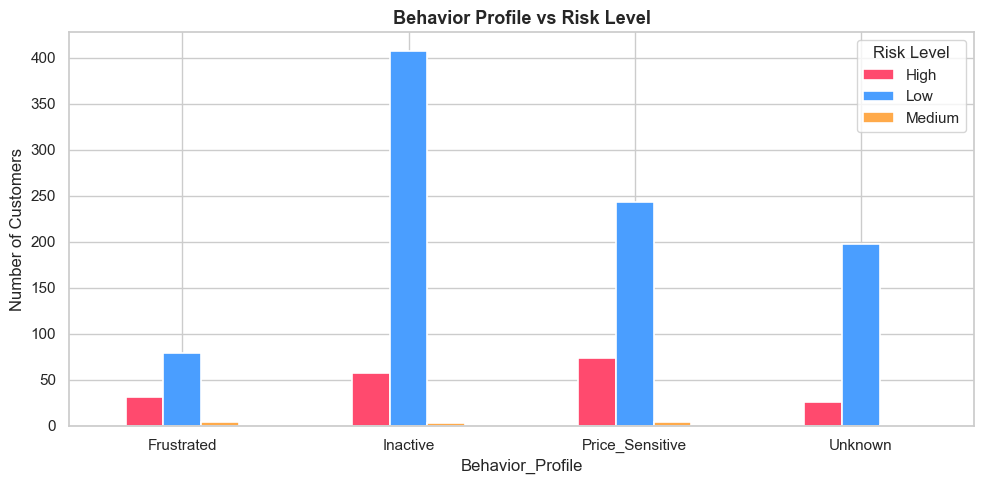

In [18]:
cross = pd.crosstab(X_test_copy['Behavior_Profile'], X_test_copy['Risk_Level'])
print(cross)

cross.plot(kind='bar', figsize=(10, 5), color=['#ff4a6e', '#4a9eff', '#ffaa4a'],
           edgecolor='white', linewidth=1.2)
plt.title('Behavior Profile vs Risk Level', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

## ⏱️ 7. Urgency Estimation — When Will They Churn?

In [19]:
def urgency(days):
    if days <= 7:
        return 'Immediate'
    elif days <= 21:
        return 'Soon'
    else:
        return 'Monitor'

X_test_copy['Urgency'] = X_test_copy['DaySinceLastOrder'].apply(urgency)
print(X_test_copy['Urgency'].value_counts())

Urgency
Immediate    863
Soon         263
Name: count, dtype: int64


## ⚡ 8. Decision Engine — What Action to Take?

In [20]:
# High risk customers by behavior + urgency
print(pd.crosstab(X_test_copy['Behavior_Profile'],
                  X_test_copy['Urgency']).loc[
    X_test_copy[X_test_copy['Risk_Level'] == 'High']['Behavior_Profile'].unique()
])

Urgency           Immediate  Soon
Behavior_Profile                 
Inactive                225   242
Price_Sensitive         321     0
Unknown                 224     0
Frustrated               93    21


In [21]:
def recommend_action(row):
    if row['Risk_Level'] != 'High':
        return 'No Action'

    b = row['Behavior_Profile']
    u = row['Urgency']

    if b == 'Frustrated' and u == 'Immediate':
        return 'Support Call Today'
    elif b == 'Frustrated' and u == 'Soon':
        return 'Apology Email + Support'
    elif b == 'Price_Sensitive' and u == 'Immediate':
        return 'Discount Offer'
    elif b == 'Inactive' and u == 'Immediate':
        return 'Re-engagement Campaign'
    elif b == 'Inactive' and u == 'Soon':
        return 'Personalized Recommendation'
    elif b == 'Unknown':
        return 'General Retention Offer'
    else:
        return 'Monitor'

X_test_copy['Recommended_Action'] = X_test_copy.apply(recommend_action, axis=1)
print(X_test_copy['Recommended_Action'].value_counts())

Recommended_Action
No Action                      938
Discount Offer                  74
Re-engagement Campaign          31
Support Call Today              27
Personalized Recommendation     26
General Retention Offer         26
Apology Email + Support          4
Name: count, dtype: int64


### 8.1 Action Distribution

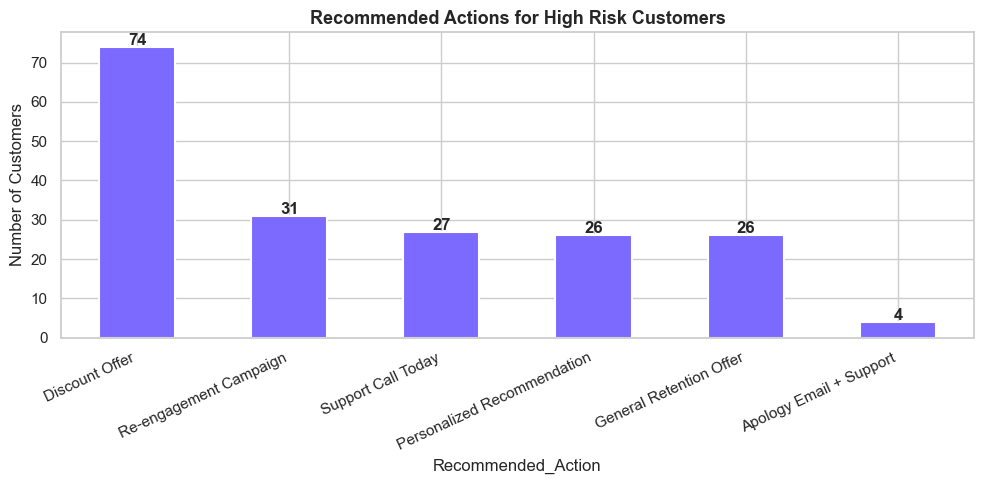

In [22]:
action_counts = X_test_copy[X_test_copy['Recommended_Action'] != 'No Action']['Recommended_Action'].value_counts()

plt.figure(figsize=(10, 5))
action_counts.plot(kind='bar', color='#7c6aff', edgecolor='white', linewidth=1.5)
plt.title('Recommended Actions for High Risk Customers', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(action_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🧪 9. Simulation — What Actually Works?

In [23]:
np.random.seed(42)

high_risk = X_test_copy[X_test_copy['Risk_Level'] == 'High'].copy()

retention_rates = {
    'Support Call Today': 0.80,
    'Apology Email + Support': 0.65,
    'Discount Offer': 0.70,
    'Re-engagement Campaign': 0.55,
    'Personalized Recommendation': 0.60,
    'General Retention Offer': 0.45
}

def simulate_outcome(action):
    rate = retention_rates.get(action, 0.3)
    return np.random.binomial(1, rate)

high_risk['Retained'] = high_risk['Recommended_Action'].apply(simulate_outcome)

results = high_risk.groupby('Recommended_Action')['Retained'].agg(['sum', 'count'])
results['Retention_Rate_%'] = (results['sum'] / results['count'] * 100).round(1)
results.columns = ['Retained', 'Total', 'Retention_Rate_%']
print(results)

                             Retained  Total  Retention_Rate_%
Recommended_Action                                            
Apology Email + Support             3      4              75.0
Discount Offer                     44     74              59.5
General Retention Offer             4     26              15.4
Personalized Recommendation        17     26              65.4
Re-engagement Campaign             21     31              67.7
Support Call Today                 22     27              81.5


### 9.1 Retention Rate by Action

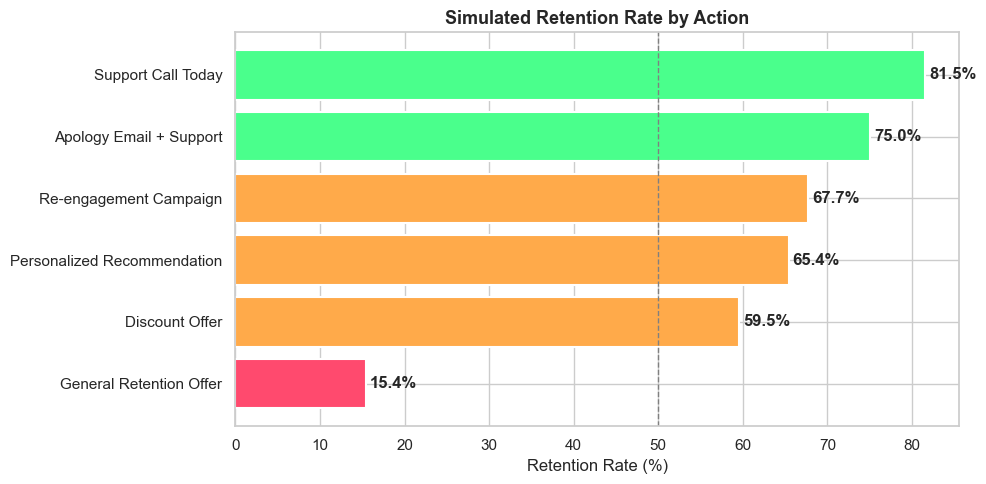

In [24]:
results_sorted = results.sort_values('Retention_Rate_%', ascending=True)
colors = ['#ff4a6e' if x < 50 else '#ffaa4a' if x < 70 else '#4aff8c'
          for x in results_sorted['Retention_Rate_%']]

plt.figure(figsize=(10, 5))
plt.barh(results_sorted.index, results_sorted['Retention_Rate_%'],
         color=colors, edgecolor='white', linewidth=1.5)
plt.axvline(50, color='gray', linestyle='--', linewidth=1, label='50% threshold')
plt.title('Simulated Retention Rate by Action', fontsize=13, fontweight='bold')
plt.xlabel('Retention Rate (%)')
for i, v in enumerate(results_sorted['Retention_Rate_%']):
    plt.text(v + 0.5, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Learning Signal

In [25]:
best = results['Retention_Rate_%'].idxmax()
worst = results['Retention_Rate_%'].idxmin()

print(f'✅ Most effective action : {best} ({results.loc[best, "Retention_Rate_%"]}%)')
print(f'❌ Least effective action: {worst} ({results.loc[worst, "Retention_Rate_%"]}%)')
print()
print('System update: Re-prioritise actions for next cycle based on these results.')

✅ Most effective action : Support Call Today (81.5%)
❌ Least effective action: General Retention Offer (15.4%)

System update: Re-prioritise actions for next cycle based on these results.
